# 📊 PathFinder: Step 1 — Exploratory Data Analysis (EDA) Processing
### End-to-End Analysis of `Student_Assessment_RAW.csv` & `Student_Career_Compatibility_RAW.csv`

This notebook performs the foundational **Exploratory Data Analysis (EDA)** required before building the new career recommendation compatibility model.

**Scope & Datasets Evaluated:**
1. **`Datasets/Student_Assessment_RAW.csv`** (10,000 student assessment records × 122 cognitive, academic, and psychometric attributes)
2. **`Datasets/Student_Career_Compatibility_RAW.csv`** (50,000 student-career interaction pairs × 15 features, including match components and ground truth target)
*(Note: `Career_Knowledge_RAW.csv` is explicitly reserved for storing careers in the database)*

### 1. Environment Setup & Library Imports

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = 'Arial'

DATA_DIR = Path("../Datasets")
print("Environment initialized successfully.")

Environment initialized successfully.


### 2. Ingestion of the Two Raw Modeling Datasets

In [2]:
path_stu = DATA_DIR / "Student_Assessment_RAW.csv"
path_comp = DATA_DIR / "Student_Career_Compatibility_RAW.csv"

df_stu = pd.read_csv(path_stu)
df_comp = pd.read_csv(path_comp)

print(f"Student Assessment Dataset      : {df_stu.shape[0]:,} rows × {df_stu.shape[1]:,} columns")
print(f"Career Compatibility Dataset   : {df_comp.shape[0]:,} rows × {df_comp.shape[1]:,} columns")

Student Assessment Dataset      : 10,000 rows × 122 columns
Career Compatibility Dataset   : 50,000 rows × 15 columns


### 3. Data Integrity & Deduplication Audit

In [3]:
stu_dups = df_stu.duplicated().sum()
comp_dups = df_comp.duplicated().sum()
unique_stu = df_stu['student_id'].nunique()
unique_comp_stu = df_comp['student_id'].nunique()
shared_stu = len(set(df_stu['student_id']) & set(df_comp['student_id']))

print("--- DATA INTEGRITY SUMMARY ---")
print(f"Assessment Duplicates     : {stu_dups} exact duplicate rows")
print(f"Compatibility Duplicates  : {comp_dups} exact duplicate rows")
print(f"Unique Students (Assess)  : {unique_stu:,} / {len(df_stu):,}")
print(f"Unique Students (Compat)  : {unique_comp_stu:,} / {len(df_comp):,}")
print(f"Student Overlap           : {shared_stu:,} ({shared_stu / unique_comp_stu * 100:.2f}% coverage)")

--- DATA INTEGRITY SUMMARY ---
Assessment Duplicates     : 10 exact duplicate rows
Compatibility Duplicates  : 150 exact duplicate rows
Unique Students (Assess)  : 9,950 / 10,000
Unique Students (Compat)  : 9,981 / 50,000
Student Overlap           : 9,931 (99.50% coverage)


### 4. Missing Values Profiling

In [4]:
stu_nulls = df_stu.isnull().sum()
comp_nulls = df_comp.isnull().sum()

print("Compatibility Columns with Missing Values:")
print(comp_nulls[comp_nulls > 0])

print(f"\nAssessment Columns with Missing Values: {(stu_nulls > 0).sum()} out of {len(df_stu.columns)} columns")
print(stu_nulls[stu_nulls > 0].head(10))

Compatibility Columns with Missing Values:
career_subdomain    200
career_cluster      200
stream              600
dtype: int64

Assessment Columns with Missing Values: 114 out of 122 columns
stream                        121
board_type                    120
assessment_completion_rate     50
response_consistency           50
confidence_in_answers          50
overall_percentage             50
mathematics_score             170
science_score                 171
english_score                 168
social_science_score          167
dtype: int64


### 5. Target Variable (`compatibility_label`) Class Balance

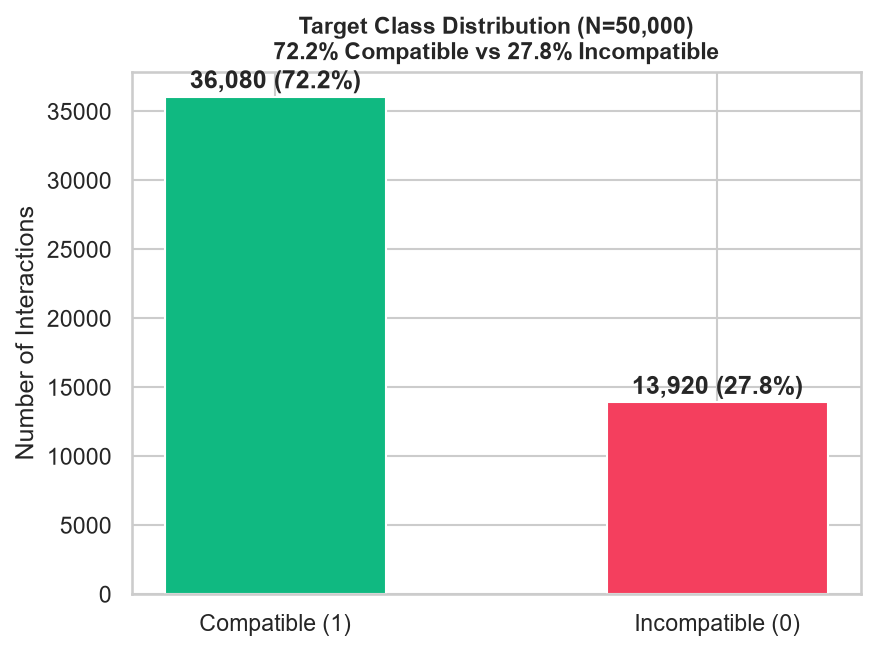

In [5]:
label_counts = df_comp['compatibility_label'].value_counts()
label_pcts = df_comp['compatibility_label'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(['Compatible (1)', 'Incompatible (0)'], label_counts.values, color=['#10B981', '#F43F5E'], width=0.5)
ax.set_title("Target Class Distribution (N=50,000)\n72.2% Compatible vs 27.8% Incompatible", fontsize=11, fontweight='bold')
ax.set_ylabel("Number of Interactions")
for bar, pct in zip(bars, label_pcts.values):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 600, f"{yval:,} ({pct:.1f}%)", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 6. Compatibility Score & Decision Cutoff Analysis (Target Leakage Audit)
> ⚠️ **CRITICAL INSIGHT:** Notice the sharp cutoff where `compatibility_score >= 70.0` maps directly to `compatibility_label = 1`. `compatibility_score` must NEVER be included as an input feature during model training to prevent target leakage.

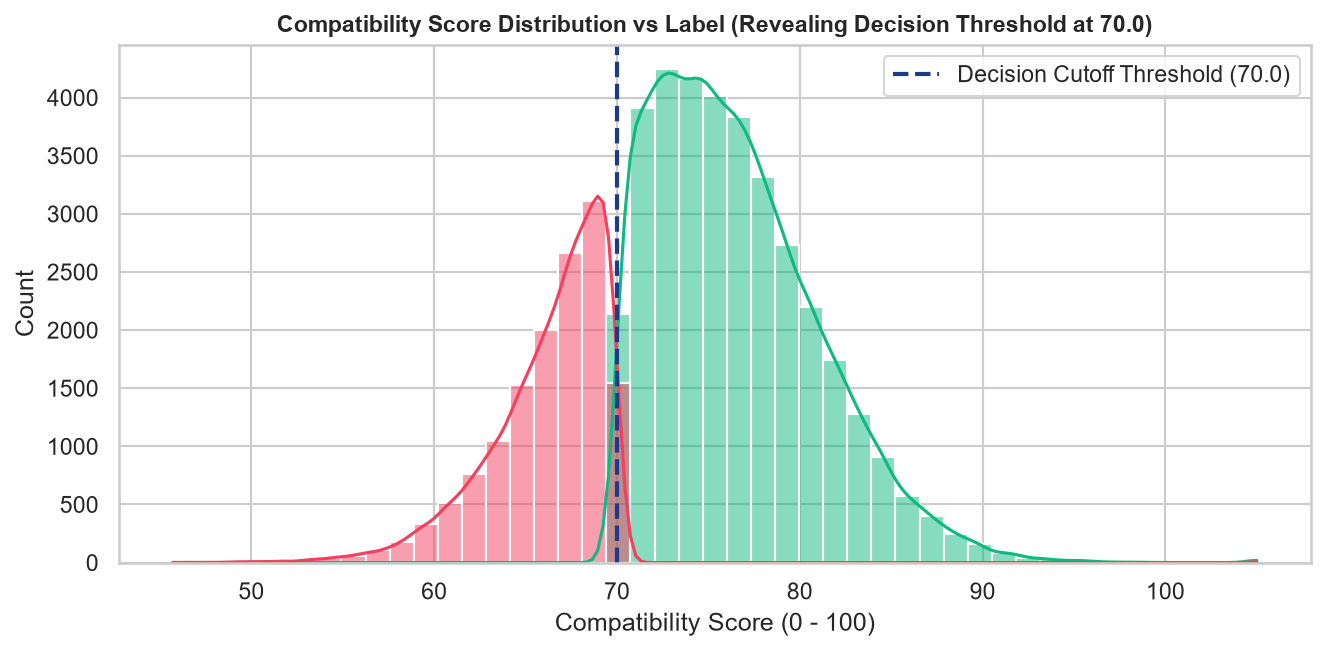

In [6]:
plt.figure(figsize=(9, 4.5))
sns.histplot(data=df_comp, x='compatibility_score', hue='compatibility_label', palette=['#F43F5E', '#10B981'], bins=45, kde=True, alpha=0.5)
plt.axvline(70.0, color='#1E3A8A', linestyle='--', linewidth=2, label='Decision Cutoff Threshold (70.0)')
plt.title("Compatibility Score Distribution vs Label (Revealing Decision Threshold at 70.0)", fontsize=11, fontweight='bold')
plt.xlabel("Compatibility Score (0 - 100)")
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

### 7. Match Components Distributions (`ability`, `interest`, `academic`, `learning`)

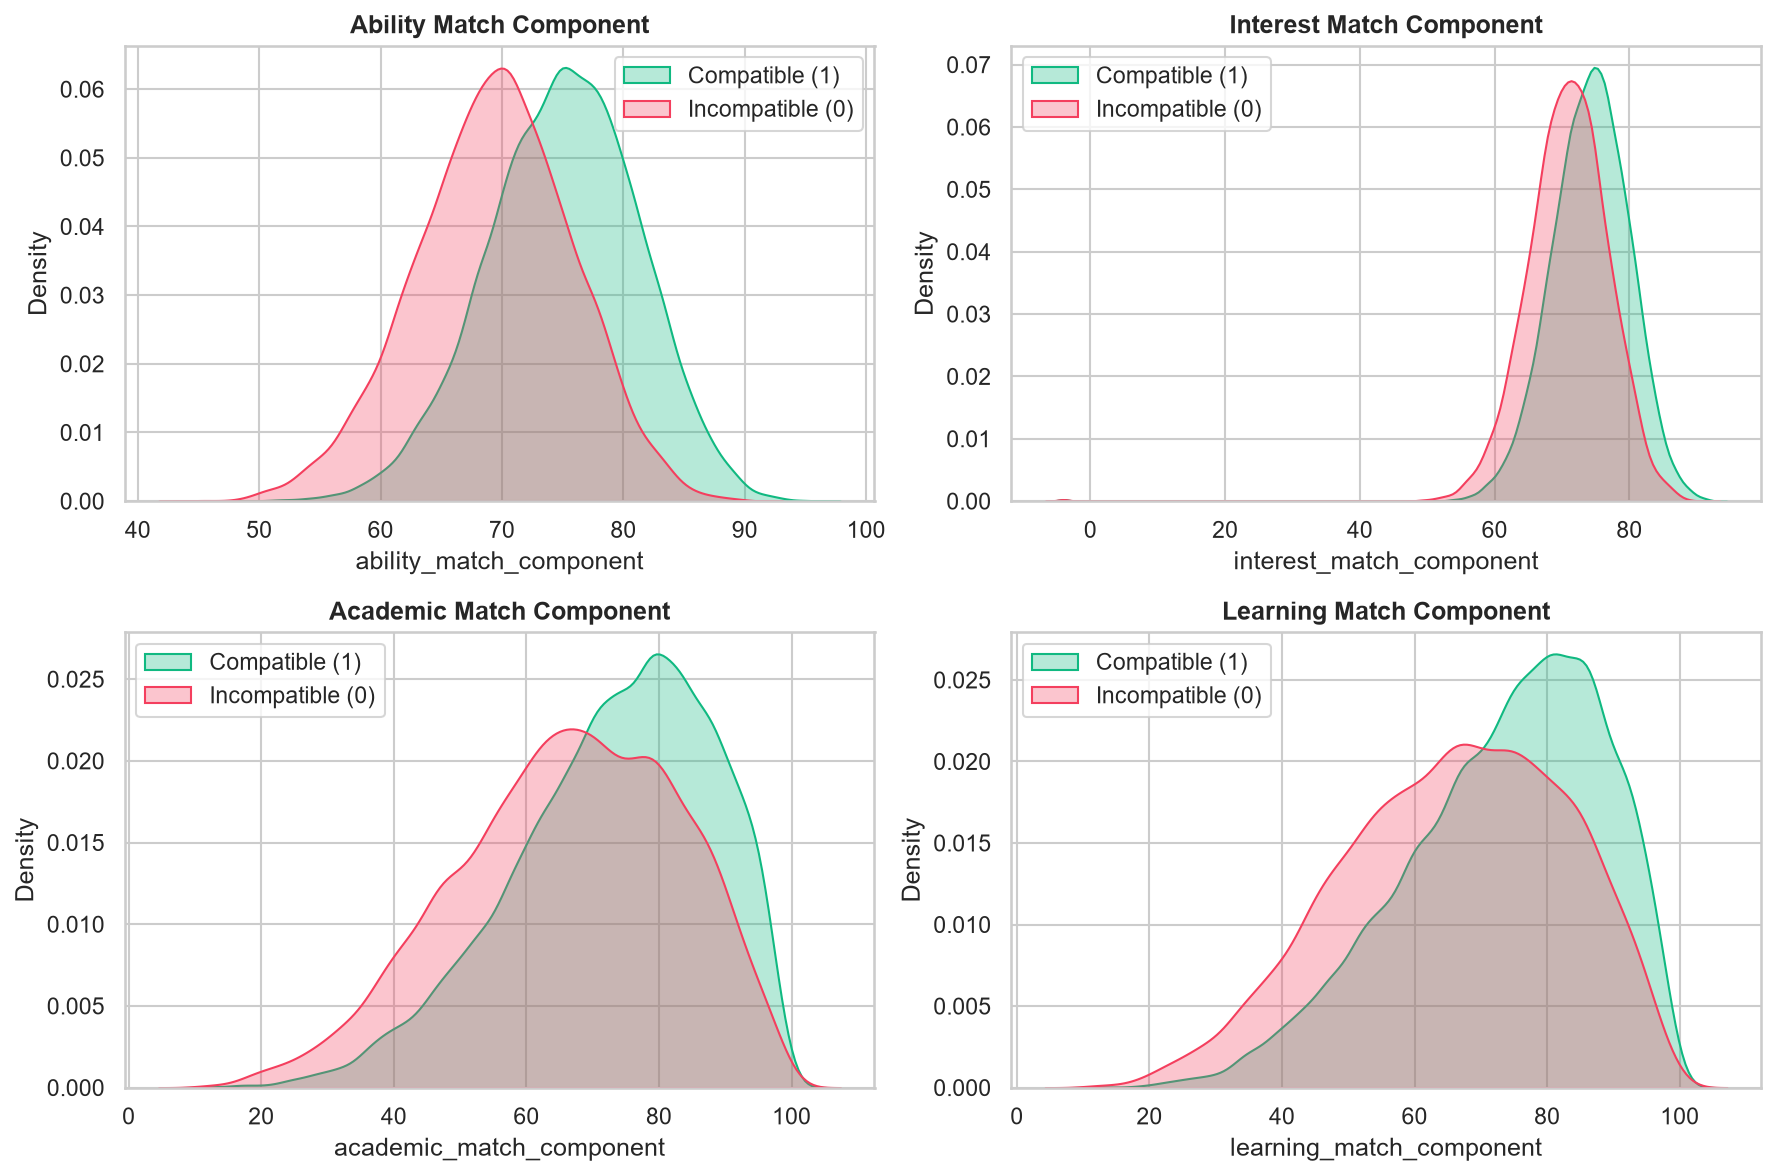

In [7]:
match_cols = ['ability_match_component', 'interest_match_component', 'academic_match_component', 'learning_match_component']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, ax in zip(match_cols, axes.flatten()):
    sns.kdeplot(data=df_comp[df_comp['compatibility_label'] == 1][col], ax=ax, label='Compatible (1)', color='#10B981', fill=True, alpha=0.3)
    sns.kdeplot(data=df_comp[df_comp['compatibility_label'] == 0][col], ax=ax, label='Incompatible (0)', color='#F43F5E', fill=True, alpha=0.3)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.legend()
plt.tight_layout()
plt.show()

### 8. Categorical Stream Sanitization Audit

In [8]:
print("Raw Stream Values (Erratic Casing & Whitespace):")
print(df_comp['stream'].value_counts(dropna=False).head(8))

cleaned_streams = df_comp['stream'].fillna('Missing').astype(str).str.strip().str.title()
print("\nSanitized Stream Proportions:")
print(cleaned_streams.value_counts(normalize=True) * 100)

Raw Stream Values (Erratic Casing & Whitespace):
stream
General        31615
Commerce        4816
Humanities      4408
Science-PCM     3963
Science-PCB     3225
 GENERAL         642
NaN              600
General          266
Name: count, dtype: int64

Sanitized Stream Proportions:
stream
General        65.062
Commerce        9.884
Humanities      9.078
Science-Pcm     8.150
Science-Pcb     6.626
Missing         1.200
Name: proportion, dtype: float64


### 9. Merged Student Profile Correlation Analysis

Merged Dataset Dimensions: 49,757 rows × 136 columns


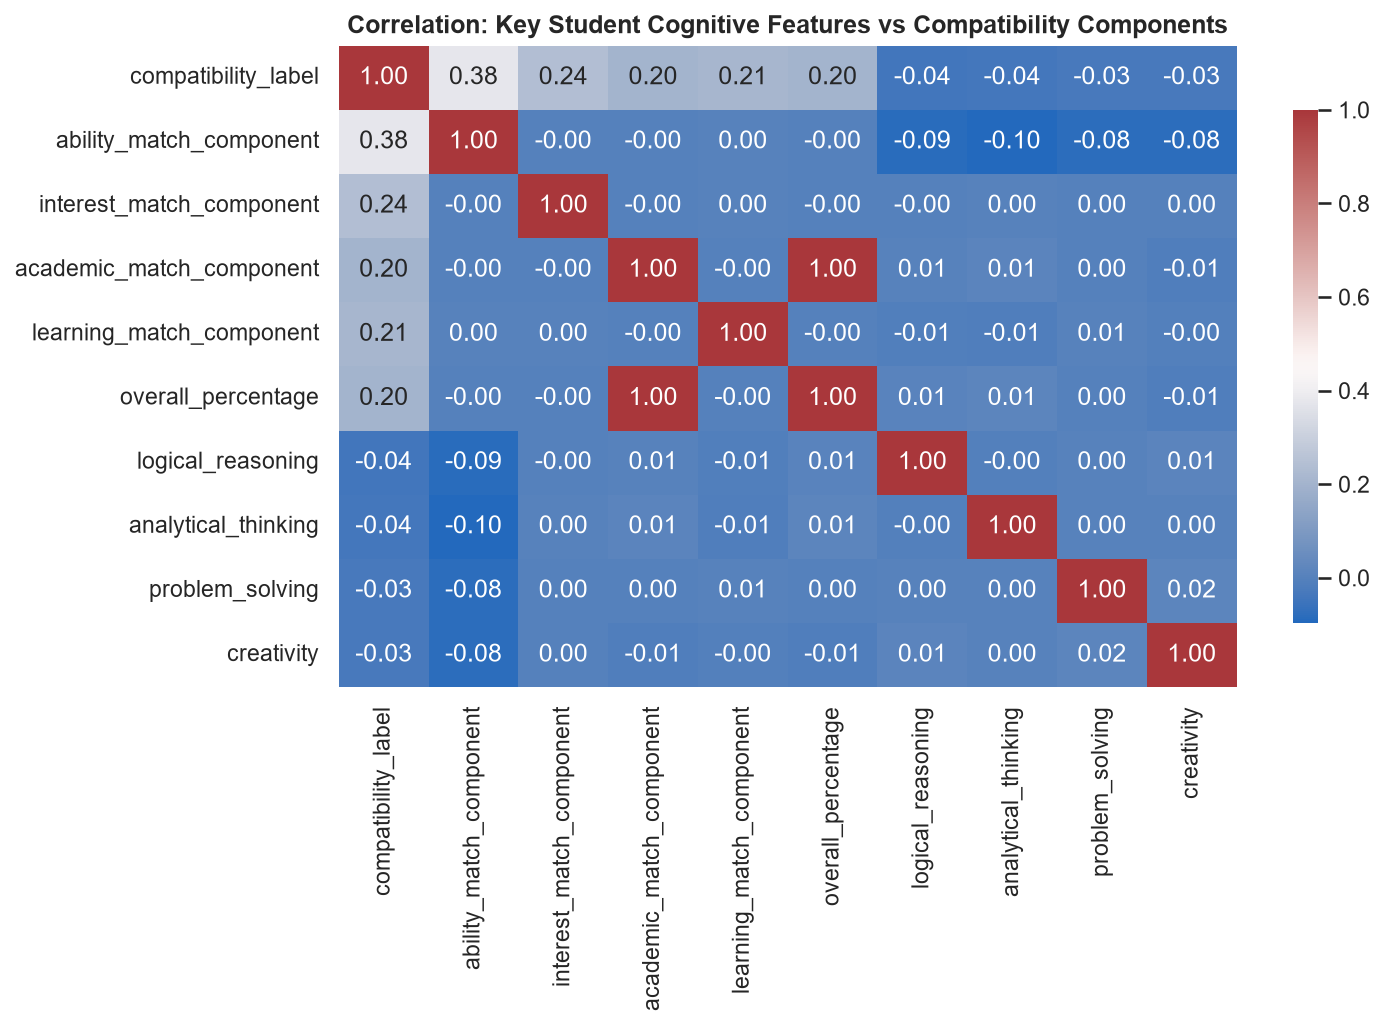

In [9]:
df_stu_dedup = df_stu.drop_duplicates(subset=['student_id'])
merged = pd.merge(df_comp, df_stu_dedup, on='student_id', how='inner', suffixes=('', '_stu'))
print(f"Merged Dataset Dimensions: {merged.shape[0]:,} rows × {merged.shape[1]:,} columns")

core_cols = ['compatibility_label', 'ability_match_component', 'interest_match_component', 'academic_match_component', 'learning_match_component', 'overall_percentage', 'logical_reasoning', 'analytical_thinking', 'problem_solving', 'creativity']
plt.figure(figsize=(10, 7))
sns.heatmap(merged[core_cols].corr(), cmap='vlag', annot=True, fmt=".2f", cbar_kws={'shrink': 0.8})
plt.title("Correlation: Key Student Cognitive Features vs Compatibility Components", fontweight='bold')
plt.tight_layout()
plt.show()

### 10. Summary of EDA Findings & Next Implementation Steps

| Finding | Observation | Remediation in Step 2 (Data Cleaning) |
| :--- | :--- | :--- |
| **Duplicates** | 10 in Assessment, 150 in Compatibility | `df.drop_duplicates()` in both datasets |
| **Dirty Categoricals** | `stream` has whitespace & casing mismatch | `.str.strip().str.title()` |
| **Missing Values** | 114 columns have ~50 missing values | SimpleImputer (median for numeric, 'Missing' for cat) |
| **Class Balance** | 72.16% Compatible vs 27.84% Incompatible | Track Macro F1 & PR-AUC, consider class weights |
| **Target Leakage** | `compatibility_score` is directly thresholded into label | **Exclude `compatibility_score` from features $X$** |
| **Partitioning** | Multiple rows per student | Use `GroupShuffleSplit` on `student_id` |